In [ ]:
import os
import requests
import aiohttp
import asyncio
import nest_asyncio
import pandas as pd
import time
import scrapy
from scrapy_playwright.page import PageMethod
from bs4 import BeautifulSoup
import nest_asyncio
import glob
import numpy as np
import matplotlib.pyplot as plt
from fuzzywuzzy import fuzz, process
import re


c:\Users\teele\anaconda3\envs\adhoc_env\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


### Kalai Data

In [ ]:
adhoc_leads = (
    pd.read_excel(r"C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Merged_Raw_Data\Kalai_Cleaned_Adhoc_Leads_1.6k\Kalai_Adhoc_Leads_Contact Number Reformatted.xlsx")
    .rename(columns=lambda c: c.upper().strip().replace(' ', '_').replace('-', '_'))
)
adhoc_leads.shape

(1674, 11)

In [ ]:
# adhoc_leads = (
#     pd.read_excel(r"C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Merged_Raw_Data\Kalai_Cleaned_Adhoc_Leads_1.6k\Kalai_Adhoc_Leads_1.xlsx")
#     .rename(columns=lambda c: c.upper().strip().replace(' ', '_').replace('-', '_'))
# )

# # Keep rows where at least one contact number is not NaN
# cols = [f'CONTACT_NUMBER_{i}' for i in range(1, 8)]
# adhoc_leads = adhoc_leads[adhoc_leads[cols].notna().any(axis=1)]

# print(adhoc_leads.shape)
# adhoc_leads.head(5)


KeyError: "None of [Index(['CONTACT_NUMBER_1', 'CONTACT_NUMBER_2', 'CONTACT_NUMBER_3',\n       'CONTACT_NUMBER_4', 'CONTACT_NUMBER_5', 'CONTACT_NUMBER_6',\n       'CONTACT_NUMBER_7'],\n      dtype='object')] are in the [columns]"

### Getting Acra Data 

In [ ]:

folder_path = "Acra_Data"

# Get all CSV file paths inside the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Read and combine all CSVs
# Using low_memory=False to avoid DtypeWarning for mixed types
df = pd.concat((pd.read_csv(f, low_memory=False) for f in csv_files), ignore_index=True)


df.columns = df.columns.str.upper()


acra_data = df[[
    "UEN",
    "ENTITY_NAME",
    "BUSINESS_CONSTITUTION_DESCRIPTION",
    "ENTITY_TYPE_DESCRIPTION",
    "ENTITY_STATUS_DESCRIPTION",
    "REGISTRATION_INCORPORATION_DATE",
    "PRIMARY_SSIC_CODE",
    "SECONDARY_SSIC_CODE",
    "STREET_NAME",
    "POSTAL_CODE"
]].copy()

# Convert to proper data types
acra_data['UEN'] = acra_data['UEN'].astype('string')
acra_data['ENTITY_NAME'] = acra_data['ENTITY_NAME'].astype('string')
acra_data['BUSINESS_CONSTITUTION_DESCRIPTION'] = acra_data['BUSINESS_CONSTITUTION_DESCRIPTION'].astype('string')
acra_data['ENTITY_TYPE_DESCRIPTION'] = acra_data['ENTITY_TYPE_DESCRIPTION'].astype('string')
acra_data['ENTITY_STATUS_DESCRIPTION'] = acra_data['ENTITY_STATUS_DESCRIPTION'].astype('string')
acra_data['REGISTRATION_INCORPORATION_DATE'] = pd.to_datetime(acra_data['REGISTRATION_INCORPORATION_DATE'], errors='coerce')

# Clean string columns — trim, remove extra spaces, uppercase
for col in [
    'UEN',
    'ENTITY_NAME',
    'BUSINESS_CONSTITUTION_DESCRIPTION',
    'ENTITY_TYPE_DESCRIPTION',
    'ENTITY_STATUS_DESCRIPTION',
    'STREET_NAME',
    'POSTAL_CODE'
]:
    acra_data[col] = (
        acra_data[col]
        .fillna('')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.upper()
    )

# Replace placeholders with NaN for standardization
acra_data.replace(['NA', 'N/A', '-', ''], np.nan, inplace=True)

# Convert registration date to dd-mm-yyyy string (optional)
acra_data['REGISTRATION_INCORPORATION_DATE'] = acra_data['REGISTRATION_INCORPORATION_DATE'].dt.strftime('%d-%m-%Y')

# Filter only live entities (LIVE COMPANY or LIVE)
acra_data = acra_data[
    acra_data['ENTITY_STATUS_DESCRIPTION'].isin(['LIVE COMPANY', 'LIVE'])
].reset_index(drop=True)

# Exclude specific PRIMARY_SSIC_CODE values (supposedly the data would be 600k plus but when we exclude this would lessen)
exclude_codes = [
    46900, 47719, 47749, 47539, 47536, 56123,
    10711, 10712, 10719, 10732, 10733, 93209
]

acra_data = acra_data[~acra_data['PRIMARY_SSIC_CODE'].isin(exclude_codes)].reset_index(drop=True)

In [ ]:
acra_data.head(5)

,UEN,ENTITY_NAME,BUSINESS_CONSTITUTION_DESCRIPTION,ENTITY_TYPE_DESCRIPTION,ENTITY_STATUS_DESCRIPTION,REGISTRATION_INCORPORATION_DATE,PRIMARY_SSIC_CODE,SECONDARY_SSIC_CODE,STREET_NAME,POSTAL_CODE
0,00182000A,AIK SENG HENG,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,07-02-1975,46302,na,FISHERY PORT ROAD,619742
1,00233500W,ASIA STORE,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,28-10-1974,46411,20234,SIMS AVENUE,387509
2,00733000J,AIK CHE HIONG,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,02-11-1974,32909,46900,ANG MO KIO INDUSTRIAL PARK 2A,568049
3,00927000X,A WALIMOHAMED BROS,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,12-11-1974,46411,66126,JELLICOE ROAD,208767
4,01173000E,ANG TECK MOH DEPARTMENT STORE,PARTNERSHIP,SOLE PROPRIETORSHIP/ PARTNERSHIP,LIVE,30-10-1974,47711,47214,WOODLANDS STREET 12,738623


In [ ]:
acra_names = acra_data[["ENTITY_NAME"]]

In [ ]:
adhoc_leads

,COMPANY_NAME,ADDRESS,CUSTOMER_NAME,EMAIL_ADDRESS,CONTACT_NUMBER,PRIMARY_SSIC,SECONDARY_SSIC,SUB_INDUSTRY,PIC_NAMES,EXTRACTED_PHONE_NUM,PIC_EMAIL__ADDRESS
0,CHAI YU TRADING,445 SIN MING AVENUE #01-473 SNG 570445,Yap Chai Ting \n 98381812,NaN,98381812,47802.0,Na,"Wet Markets, Market Stalls & Street Retailers",YAP CHAI TING,98381812,NaN
1,38 VEGETARIAN,"CAUSEWAY POINT, 1, WOODLANDS SQUARE, #B1-K17, ...",Ms. Jenny Ho 9839 5558,NaN,NaN,47219.0,56140,"Wet Markets, Market Stalls & Street Retailers",MS. JENNY HO,98395558,NaN
2,FIRST STATION (T1) PTE. LTD.,HOUSE 80 AIRPORT BOULEVARD MAIN CHANGI AIRPORT...,MS SHIRLEY 98265862 64456030 choicefood@ymail.com,choicefood@ymail.com,98265862,47219.0,na,"Wet Markets, Market Stalls & Street Retailers",MS SHIRLEY,98265862 / 64456030,choicefood@ymail.com
3,DE CHENG XIN XING TRADING PTE LTD,1775 GEYLANG BAHRU #01-03 Singapore 339704,MS HELEN CHEUNG LIU SUK MS NICOLE 63772683 972...,heng328@singnet.com.sg,63772683,47219.0,56111,"Wet Markets, Market Stalls & Street Retailers",MS HELEN CHEUNG LIU SUK MS NICOLE,63772683 / 97262668,heng328@singnet.com.sg
4,COCOA COLONY (S) PTE. LTD.,HOUSE 1 VISTA EXCHANGE GREEN #01-50 THE STAR S...,Mr. Kenny Koh Ms. Wendy 9106 1958 9693 120,NaN,NaN,47213.0,56112,"Wet Markets, Market Stalls & Street Retailers",MR. KENNY KOH MS. WENDY,91061958,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1669,NOVO PTE LTD,"201 VICTORIA STREET, #04-01 ILUMA, Singapore 1...",Andy Yao 91825977 chihung@rsh.com.sg,chihung@rsh.com.sg,91825977,NaN,Na,0,ANDY YAO,91825977,chihung@rsh.com.sg
1670,COMBIND SUPPLIES PTE LTD,"80, JOO KOON CIRCLE, MAIN, 629100",ALEX – alec@combinesupplies.com 91541319,alec@combinesupplies.com,91541319,24202.0,Na,0,ALEX,91541319,alec@combinesupplies.com
1671,ICELL NETWORK PTE LTD,2 SERANGOON ROAD #01-00 THE VERGE SNG 218227,Adrian – 93657107\n Adrian.lee@icellnetwork.com,Adrian.lee@icellnetwork.com,93657107,61092.0,62021,0,ADRIAN,93657107,adrian.lee@icellnetwork.com
1672,ST SME OPCO01,"231 BAIN STREET, #02-93 , Singapore 180231",Mr Teh Lian Sin Keith 93362606 91185579,NaN,93362606,NaN,Na,NaN,MR TEH LIAN SIN KEITH,93362606 / 91185579,NaN


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def preprocess_company_name(name):
    """
    OPTIMIZED preprocessing for company names.
    Removes common suffixes, special characters, and standardizes format.
    """
    if pd.isna(name):
        return ""

    name = str(name).upper().strip()
    name = re.sub(r'[^\w\s]', ' ', name)

    suffixes = [
        'PRIVATE LIMITED', 'PTE LTD', 'PTE. LTD.', 'PTE LTD.', 'PTE. LTD',
        'PVT LTD', 'LIMITED', 'LTD', 'SINGAPORE', 'S.G.', 'SG', 'PTE',
        'COMPANY', 'CO', 'CORPORATION', 'CORP', 'INC', 'INCORPORATED',
        'LLC', 'LLP', 'PROPRIETARY', 'PROP'
    ]

    for suffix in suffixes:
        if name.endswith(' ' + suffix):
            name = name[:-len(suffix)-1].strip()
        elif name == suffix:
            name = ""

    name = re.sub(r'\s+', ' ', name).strip()
    return name

# Preprocess both datasets
company_names_clean = adhoc_leads['COMPANY_NAME'].apply(preprocess_company_name)
acra_names_clean = acra_names['ENTITY_NAME'].apply(preprocess_company_name)

# OPTIMIZED TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    lowercase=True,
    max_df=0.90,
    min_df=1,
    strip_accents='unicode',
    sublinear_tf=True
)

# Fit and transform
all_names = pd.concat([company_names_clean, acra_names_clean], ignore_index=True)
vectorizer.fit(all_names)
tfidf_company = vectorizer.transform(company_names_clean)
tfidf_acra = vectorizer.transform(acra_names_clean)

# ============================================================================
# OPTIMIZED MEMORY-EFFICIENT BATCH PROCESSING
# ============================================================================
BATCH_SIZE = 100
PERFECT_THRESHOLD = 1.00
HIGH_QUALITY_THRESHOLD = 0.85

match_results = []
total_batches = (len(adhoc_leads) + BATCH_SIZE - 1) // BATCH_SIZE

for batch_num in range(total_batches):
    start_idx = batch_num * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, len(adhoc_leads))

    batch_similarities = cosine_similarity(tfidf_company[start_idx:end_idx], tfidf_acra)

    for i, company_idx in enumerate(range(start_idx, end_idx)):
        scores = batch_similarities[i]
        best_acra_idx = np.argmax(scores)
        best_score = scores[best_acra_idx]

        match_results.append({
            'company_idx': company_idx,
            'ENTITY_NAME': acra_data.iloc[best_acra_idx]['ENTITY_NAME'],
            'UEN': acra_data.iloc[best_acra_idx]['UEN'],
            'SIMILARITY_SCORE': round(best_score, 4)
        })

# Create match results dataframe and merge with adhoc_leads
match_df = pd.DataFrame(match_results)

# Merge to maintain all columns from adhoc_leads
adhoc_leads_with_matches = adhoc_leads.copy()
adhoc_leads_with_matches['ENTITY_NAME'] = match_df['ENTITY_NAME'].values
adhoc_leads_with_matches['UEN'] = match_df['UEN'].values
adhoc_leads_with_matches['SIMILARITY_SCORE'] = match_df['SIMILARITY_SCORE'].values

# Create 3-tier dataframes
perfect_match_df = adhoc_leads_with_matches[
    adhoc_leads_with_matches['SIMILARITY_SCORE'] == PERFECT_THRESHOLD
].reset_index(drop=True)

high_quality_df = adhoc_leads_with_matches[
    (adhoc_leads_with_matches['SIMILARITY_SCORE'] >= HIGH_QUALITY_THRESHOLD) &
    (adhoc_leads_with_matches['SIMILARITY_SCORE'] < PERFECT_THRESHOLD)
].reset_index(drop=True)

low_quality_df = adhoc_leads_with_matches[
    adhoc_leads_with_matches['SIMILARITY_SCORE'] < HIGH_QUALITY_THRESHOLD
].reset_index(drop=True)

# Final summary
print(f"\n{'='*70}")
print("DATAFRAMES CREATED:")
print(f"{'='*70}")
print(f"  perfect_match_df : {len(perfect_match_df):,} rows (100% similarity)")
print(f"  high_quality_df  : {len(high_quality_df):,} rows (85%-99% similarity)")
print(f"  low_quality_df   : {len(low_quality_df):,} rows (<85% similarity)")


DATAFRAMES CREATED:
  perfect_match_df : 471 rows (100% similarity)
  high_quality_df  : 644 rows (85%-99% similarity)
  low_quality_df   : 559 rows (<85% similarity)


In [ ]:
import pandas as pd
from openpyxl import load_workbook

# --- Combine DataFrames (perfect_match_df (Kalai) and high_quality_df (Kalai)) ---
combined_perfect_hq = pd.concat([perfect_match_df, high_quality_df], ignore_index=True)
print(len(combined_perfect_hq))

# Rename columns
combined_perfect_hq.rename(columns={
    'CUSTOMER_NAME': 'PIC_NAME',
    'CONTACT_NUMBER': 'CONTACT_NUMBER_1_FORMATTED'
}, inplace=True)


def append_combined_perfect_hq_to_high_quality_leads(filename, df_new, sheet_name="high_quality_leads"):

    # Load existing sheet into a DataFrame
    df_existing = pd.read_excel(filename, sheet_name=sheet_name)

    # --- Align columns ---
    # Keep only columns that exist in the Excel sheet
    df_to_append = df_new[[col for col in df_existing.columns if col in df_new.columns]]

    # Create a copy of missing columns in df_new (if any)
    for col in df_existing.columns:
        if col not in df_to_append.columns:
            df_to_append[col] = None  # Fill missing columns with None

    # Reorder to match exact Excel sheet structure
    df_to_append = df_to_append[df_existing.columns]

    # Append to existing Excel
    df_final = pd.concat([df_existing, df_to_append], ignore_index=True)

    # Save back to file
    with pd.ExcelWriter(filename, engine="openpyxl", mode="w") as writer:
        df_final.to_excel(writer, sheet_name=sheet_name, index=False)


filename = r"C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Join_ACRA\high_quality_leads.xlsx"

append_combined_perfect_hq_to_high_quality_leads(filename, combined_perfect_hq)

# Count rows after append
df_after = pd.read_excel(filename, sheet_name="high_quality_leads")
print("Number of rows:", len(df_after))

1115


C:\Users\teele\AppData\Local\Temp\ipykernel_23416\427284107.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_append[col] = None  # Fill missing columns with None
C:\Users\teele\AppData\Local\Temp\ipykernel_23416\427284107.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_append[col] = None  # Fill missing columns with None
C:\Users\teele\AppData\Local\Temp\ipykernel_23416\427284107.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

Number of rows: 3192


In [ ]:
low_quality_df.to_csv("./low_quality_df.csv")

In [ ]:
perfect_match_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE", "UEN"]].head(10)

,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE,UEN
0,CHAI YU TRADING,CHAI YU TRADING,1.0,53188134B
1,FIRST STATION (T1) PTE. LTD.,FIRST STATION (T1) PTE. LTD.,1.0,201101956D
2,DE CHENG XIN XING TRADING PTE LTD,DE CHENG XIN XING TRADING PTE LTD,1.0,198901553R
3,EXPOFIN PTE LTD,EXPOFIN PTE LTD,1.0,198903335R
4,ELG UTICA ALLOYS SINGAPORE PTE. LTD.,ELG UTICA ALLOYS SINGAPORE PTE. LTD.,1.0,201531754C
5,GREENWAY ENVIRONMENTAL WASTE MANAGEMENT PTE. LTD.,GREENWAY ENVIRONMENTAL WASTE MANAGEMENT PTE. LTD.,1.0,200412740R
6,GKE WAREHOUSING & LOGISTICS PTE LTD,GKE WAREHOUSING & LOGISTICS PTE LTD,1.0,199802235G
7,TANKSTORE,TANKSTORE,1.0,52946388A
8,RONG DE DISTRIBUTION PTE LTD,RONG DE DISTRIBUTION PTE LTD,1.0,199701865M
9,QUALITY TRANSPORT (S) PTE LTD,QUALITY TRANSPORT (S) PTE LTD,1.0,199003595N


In [ ]:
high_quality_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE"]].head(10)

,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE
0,38 VEGETARIAN,VEGETARIAN PRIVATE LIMITED,0.8822
1,COCOA COLONY (S) PTE. LTD.,COCOA COLONY PTE. LTD.,0.9928
2,SUZETTE INTERNATIONAL PTE. LTD,SUZETTE INTERNATIONAL PTE. LTD.,0.9936
3,CARAMELCRISP PTE LTD,CARAMELCRISP PTE. LTD.,0.9942
4,TALK COCK SING SONG @ THOMSON PTE LTD,TALK COCK SING SONG @ THOMSON PTE. LTD.,0.9941
5,CARAMELCRISP PTE LTD,CARAMELCRISP PTE. LTD.,0.9942
6,V8 ENVIRONMENT PTE LTD,V8 ENVIRONMENTAL PTE LTD,0.9177
7,BIOFUEL INDUSTRIES PTE LTD,BIOFUEL INDUSTRIES PTE. LTD.,0.9930
8,TEL TRANSPORT & WAREHOUSING PTE LTD,TEL TRANSPORT & WAREHOUSING PTE. LTD.,0.9934
9,MEDIACORP PTE LTD,MEDIACORP PTE. LTD.,0.9883


In [ ]:
low_quality_df[["COMPANY_NAME", "ENTITY_NAME", "SIMILARITY_SCORE"]].head(10)


,COMPANY_NAME,ENTITY_NAME,SIMILARITY_SCORE
0,AL-KHAIR SHOPPE,FOOD SHOPPE (PTE. LTD.),0.6144
1,ESTON INTERNATIONAL PTE. LTD,BESTON INTERNATIONAL TRADING PTE. LTD.,0.7161
2,SQEEN BRIDAL COUTURE,L.A.B. BRIDAL COUTURE PTE. LTD.,0.7085
3,MORELASTIC GREEN RESOURCES PTE LTD,STAR GREEN RESOURCES PTE. LTD.,0.5869
4,KIM HOCK CORPORATION PTE LTD,KIM HOCK FOOD TRADING PTE LTD,0.7369
5,RICA LEASING PTE LTD,A&L LEASING PRIVATE LIMITED,0.6993
6,TRIJAYA GLOBAL INTERNATIONAL (PTE) LTD,TRIJAYA GLOBAL FOOD PTE. LTD.,0.8021
7,TRANSMILE AIR SERVICES SDN BHD,KOON SANG AIR CON SERVICE SDN. BHD,0.5609
8,MINISTRY OF EDUCATION,MINISTRY OF TEA,0.7079
9,EZYBOX LEARNING HUB PTE LTD,EZYBOX TUITION CENTRE,0.6125


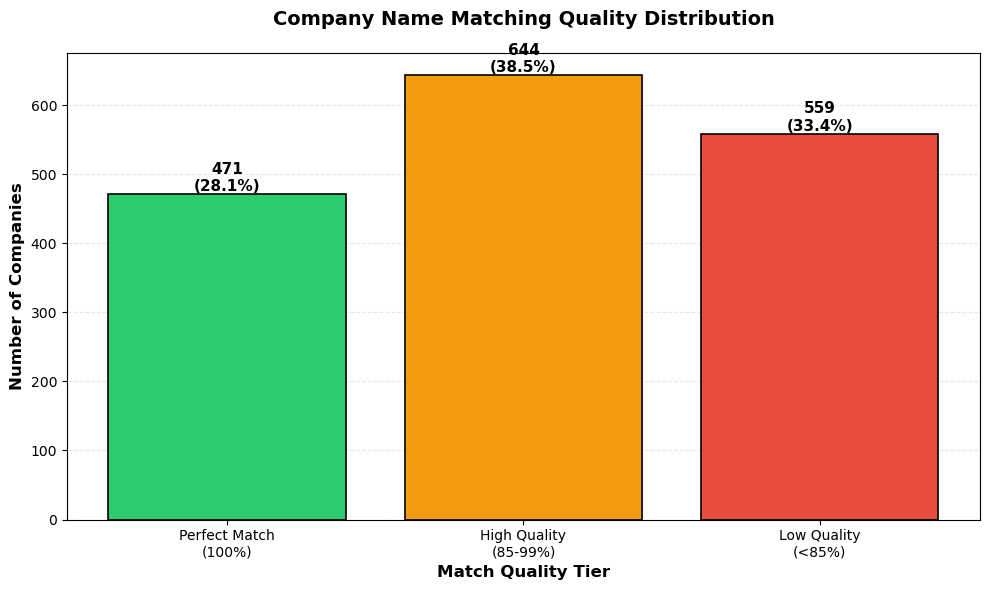


Total companies processed: 1,674


In [ ]:
# Create column chart for match quality distribution
import matplotlib.pyplot as plt

# Prepare data
categories = ['Perfect Match\n(100%)', 'High Quality\n(85-99%)', 'Low Quality\n(<85%)']
counts = [len(perfect_match_df), len(high_quality_df), len(low_quality_df)]
percentages = [
    (len(perfect_match_df) / len(adhoc_leads)) * 100,
    (len(high_quality_df) / len(adhoc_leads)) * 100,
    (len(low_quality_df) / len(adhoc_leads)) * 100
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars with custom colors
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize chart
ax.set_ylabel('Number of Companies', fontsize=12, fontweight='bold')
ax.set_xlabel('Match Quality Tier', fontsize=12, fontweight='bold')
ax.set_title('Company Name Matching Quality Distribution', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f"\nTotal companies processed: {len(adhoc_leads):,}")

### Download output as Excel files

In [ ]:
# import pandas as pd

# # Path where you want to save the Excel file
# output_path = r"C:\Users\teele\Documents\GitHub\Adhoc_Leads_Refinement_Pipeline\10k_adhoc_leads\Merged_Raw_Data\Merge_Kalai_and_Ish\perfect_match_output.xlsx"

# # Save only the selected columns (optional)
# perfect_match_df[
# ["COMPANY_NAME", 
# "ENTITY_NAME", 
# "SIMILARITY_SCORE", 
# "UEN", 
# "PIC_NAME", 
# "DESIGNATION", 
# "CONTACT_NUMBER_1_FORMATTED", 
# "CONTACT_NUMBER_2_FORMATTED",
# "CONTACT_NUMBER_3_FORMATTED",
# "CONTACT_NUMBER_4_FORMATTED",
# "CONTACT_NUMBER_5_FORMATTED",
# "CONTACT_NUMBER_6_FORMATTED",
# "CONTACT_NUMBER_7_FORMATTED",
# "ADDRESS",
# "EMAIL_1",
# "EMAIL_2",
# "EMAIL_3",
# "EMAIL_4",
# "EMAIL_5",
# "EMAIL_6",
# "EMAIL_7"
# ]
# ].to_excel(
#     output_path,
#     index=False
# )

# print("File saved successfully:", output_path)


In [ ]:
# list(perfect_match_df.columns)


In [ ]:
https://recordowl.com/search?name={name of the business}

SyntaxError: invalid syntax (2390193072.py, line 1)

In [ ]:
low_quality_df